# PSID Generic Crisis Module — NLP Optimization Pipeline

**Project:** Panel Study of Income Dynamics (PSID)
**Directed by:** Thomas Crossley
**Team:** PSID Survey Methodology Group

---

## Objective

This notebook implements a **Natural Language Processing (NLP)** and
**mathematical optimization** pipeline to rank historical PSID survey
questions for inclusion in a pre-specified **Generic Crisis Module**.

The pipeline:

1. **Ingests** survey questions from the Financial Constructs workbook,
   the Item Classification workbook, and PDF-sourced crisis modules.
2. **Extracts keywords** using RAKE (Rapid Automatic Keyword Extraction)
   and spaCy noun-phrase chunking.
3. **Tags keywords** against a hand-curated crisis-construct taxonomy
   with predetermined impact weights.
4. **Scores every question** using the Utility-Burden formulation:

$$R_i = \frac{U_i}{B_i}$$

where $U_i = \sum_{k \in K_i} w_k$ and $B_i = \alpha N_i + \beta C_i$.

5. **Visualises** results so leadership can finalise the module.

## 1. Environment Setup

In [1]:
# ──────────────────────────────────────────────────────────────────────────
# 1.  IMPORTS & CONFIGURATION
# ──────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import spacy
from rake_nltk import Rake
from collections import defaultdict
import textwrap, re, os

# Download NLTK data required by rake-nltk
import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("punkt", quiet=True)

# Load spaCy English model for noun-phrase chunking
nlp = spacy.load("en_core_web_sm")

# Seaborn style
sns.set_theme(style="whitegrid", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "sans-serif",
})

print("Environment ready.")

Environment ready.


## 2. Data Ingestion

We load questions from **three complementary sources** stored in the workspace:

| Source file | Sheet / Section | Content |
|---|---|---|
| `Financial Constructs.xlsx` | *Govt Shutdown* | 2019 Federal Shutdown income & coping questions |
| `Financial Constructs.xlsx` | *COVID_19* | 2021 Pandemic economic-impact items |
| `Item Classification.xlsx` | *Questions* | Understanding Society baseline demographics |

Questions that are empty or purely structural headers are dropped.

In [2]:
# ──────────────────────────────────────────────────────────────────────────
# 2.  DATA INGESTION — load all survey questions from workspace Excel files
# ──────────────────────────────────────────────────────────────────────────

# ---------- paths (adjust if your workspace layout differs) ---------------
FINANCIAL = "Financial Constructs.xlsx"
ITEMCLASS = "Item Classification.xlsx"

# Try workspace-mounted path first, fall back to current directory
for base in ["/sessions/eager-busy-hopper/mnt/Modules_Questions/", "./"]:
    if os.path.exists(os.path.join(base, FINANCIAL)):
        DATA_DIR = base
        break

# ---------- 2a. Government Shutdown 2019 questions ------------------------
shutdown_raw = pd.read_excel(
    os.path.join(DATA_DIR, FINANCIAL),
    sheet_name="Govt Shutdown",
    header=None,
)
# Column 0 holds question text; keep non-null, non-header rows
shutdown_qs = (
    shutdown_raw[0]
    .dropna()
    .astype(str)
    .str.strip()
    .loc[lambda s: s.str.len() > 10]           # drop very short labels
    .reset_index(drop=True)
)
# Tag section: rows before "GOVERNMENT SHUTDOWN" header → generic income
split_idx = shutdown_qs[
    shutdown_qs.str.contains("GOVERNMENT SHUTDOWN", case=False)
].index
if len(split_idx):
    generic_income_qs = shutdown_qs.iloc[1:split_idx[0]]
    crisis_shutdown_qs = shutdown_qs.iloc[split_idx[0]+1:]
else:
    generic_income_qs = shutdown_qs.iloc[1:]
    crisis_shutdown_qs = pd.Series(dtype=str)

# ---------- 2b. COVID-19 Pandemic questions -------------------------------
covid_raw = pd.read_excel(
    os.path.join(DATA_DIR, FINANCIAL),
    sheet_name="COVID_19",
    header=None,
)
covid_qs = (
    covid_raw[0]
    .dropna()
    .astype(str)
    .str.strip()
    .loc[lambda s: s.str.len() > 10]
    .iloc[1:]                                    # skip header row
    .reset_index(drop=True)
)

# ---------- 2c. Understanding Society baseline (Item Classification) ------
ic_raw = pd.read_excel(
    os.path.join(DATA_DIR, ITEMCLASS),
    sheet_name="Questions",
)
ic_raw.columns = ["Module", "QID", "QuestionText", "Type"]
ic_qs = ic_raw.dropna(subset=["QuestionText"]).copy()

# ---------- 2d. Combine into a single master DataFrame --------------------
rows = []
for q in generic_income_qs:
    rows.append({"question_text": q, "source": "Govt Shutdown (Income)",
                 "module_type": "Generic", "crisis_origin": "Shutdown 2019"})
for q in crisis_shutdown_qs:
    rows.append({"question_text": q, "source": "Govt Shutdown (Crisis)",
                 "module_type": "Crisis-Specific", "crisis_origin": "Shutdown 2019"})
for q in covid_qs:
    rows.append({"question_text": q, "source": "COVID-19",
                 "module_type": "Crisis-Specific", "crisis_origin": "COVID-19 2021"})
for _, r in ic_qs.iterrows():
    rows.append({"question_text": str(r["QuestionText"]),
                 "source": "Understanding Society",
                 "module_type": str(r.get("Type", "Generic")),
                 "crisis_origin": "Understanding Society"})

df = pd.DataFrame(rows)
# Clean question text — remove system placeholders
df["question_text"] = (
    df["question_text"]
    .str.replace(r"\[.*?\]", "", regex=True)   # remove bracketed tokens
    .str.replace(r"\n", " ", regex=True)
    .str.strip()
)
df = df[df["question_text"].str.len() > 5].reset_index(drop=True)

print(f"Total questions ingested: {len(df)}")
print(df["source"].value_counts().to_string())
df.head(10)

Total questions ingested: 103
source
Govt Shutdown (Income)    57
COVID-19                  20
Govt Shutdown (Crisis)    19
Understanding Society      7


,question_text,source,module_type,crisis_origin
0,Whether Reference Person or Spouse/Partner is ...,Govt Shutdown (Income),Generic,Shutdown 2019
1,"What were total receipts from farming in , inc...",Govt Shutdown (Income),Generic,Shutdown 2019
2,What were ’s) / ’s] / ’s / ’s and ’s] total op...,Govt Shutdown (Income),Generic,Shutdown 2019
3,What was the net income from farming?,Govt Shutdown (Income),Generic,Shutdown 2019
4,Did ] own a business at any time in or have ...,Govt Shutdown (Income),Generic,Shutdown 2019
5,How many businesses or financial interests did...,Govt Shutdown (Income),Generic,Shutdown 2019
6,What kind of business was that?,Govt Shutdown (Income),Generic,Shutdown 2019
7,What was the name of (the/that) business?,Govt Shutdown (Income),Generic,Shutdown 2019
8,Who in the family owned that business?,Govt Shutdown (Income),Generic,Shutdown 2019
9,Did ] put in any work time for this business in ?,Govt Shutdown (Income),Generic,Shutdown 2019


## 3. NLP Pipeline — Keyword Extraction

We run **two complementary extractors** on each question:

1. **RAKE** — scores multi-word keyphrases by co-occurrence frequency
   and degree (prefers longer, rarer phrases).
2. **spaCy noun-phrase chunking** — captures compact noun phrases that
   RAKE sometimes splits.

The union of both sets gives us the richest keyword pool for downstream
semantic tagging.

In [3]:
# ──────────────────────────────────────────────────────────────────────────
# 3.  NLP PIPELINE — RAKE + spaCy keyword extraction
# ──────────────────────────────────────────────────────────────────────────

rake = Rake(
    min_length=1,
    max_length=4,
    include_repeated_phrases=False,
)

def extract_keywords(text: str) -> list[str]:
    # Return deduplicated keywords from RAKE + spaCy for a single question.
    kws = set()

    # --- RAKE ---
    rake.extract_keywords_from_text(text)
    for score, phrase in rake.get_ranked_phrases_with_scores():
        if score >= 1.0:                         # keep phrases scored >=1
            kws.add(phrase.lower().strip())

    # --- spaCy noun-phrase chunks ---
    doc = nlp(text)
    for chunk in doc.noun_chunks:
        clean = chunk.text.lower().strip()
        if len(clean) > 2:                       # skip very short chunks
            kws.add(clean)

    return sorted(kws)

# Apply to every question
df["keywords"] = df["question_text"].apply(extract_keywords)
df["n_keywords"] = df["keywords"].apply(len)

# Show sample
print("Sample keyword extraction:")
for _, row in df.head(5).iterrows():
    print(f"  Q: {row['question_text'][:80]}...")
    print(f"     Keywords: {row['keywords'][:6]}")
    print()

Sample keyword extraction:
  Q: Whether Reference Person or Spouse/Partner is a Farmer or Rancher on Current Mai...
     Keywords: ['a farmer', 'current main job', 'farmer', 'partner', 'rancher', 'reference person']

  Q: What were total receipts from farming in , including soil bank payments and comm...
     Keywords: ['commodity credit loans', 'farming', 'including soil bank payments', 'soil bank payments', 'total receipts', 'what']

  Q: What were ’s) / ’s] / ’s / ’s and ’s] total operating expenses, not counting liv...
     Keywords: ['/ ’s] / ’s / ’s and ’s] total operating expenses', 'counting living expenses', 'living expenses', 'total operating expenses', 'what', '’']

  Q: What was the net income from farming?...
     Keywords: ['farming', 'net income', 'the net income', 'what']

  Q: Did ]  own a business at any time in  or have a financial interest in any busine...
     Keywords: ['a business', 'a financial interest', 'any business enterprise', 'any time', 'business', 'busin

## 4. Semantic Taxonomy & Impact Weights

Each keyword is mapped to one or more **crisis constructs**.  The impact
weight $w_k$ reflects how analytically valuable that keyword is for
measuring crisis effects.  Weights were set by the research team based on
PSID longitudinal priorities:

| Construct | Weight | Example keywords |
|---|---|---|
| Economic / Income | 0.80 | income, earnings, wages, receipts |
| Employment | 0.75 | furloughed, laid off, working, job |
| Financial Coping | 0.85 | savings, credit card, retirement, food bank |
| Housing / Shelter | 0.90 | rent, mortgage, home, foreclosure |
| Government Aid | 0.70 | stimulus, unemployment insurance, paycheck protection |
| Trauma / Health | 0.90 | pandemic, damage, evacuation, health |
| Demographics | 0.50 | age, sex, date of birth, resident |

In [4]:
# ──────────────────────────────────────────────────────────────────────────
# 4.  SEMANTIC TAXONOMY — keyword → construct → impact weight
# ──────────────────────────────────────────────────────────────────────────

# Master taxonomy: keyword fragment → (construct, weight)
TAXONOMY: dict[str, tuple[str, float]] = {
    # ── Economic / Income (w = 0.80) ─────────────────────────────────────
    "income":           ("Economic / Income",    0.80),
    "net income":       ("Economic / Income",    0.80),
    "earnings":         ("Economic / Income",    0.80),
    "wages":            ("Economic / Income",    0.80),
    "salary":           ("Economic / Income",    0.80),
    "salaries":         ("Economic / Income",    0.80),
    "receipts":         ("Economic / Income",    0.80),
    "operating expenses": ("Economic / Income",  0.80),
    "bonuses":          ("Economic / Income",    0.80),
    "overtime":         ("Economic / Income",    0.80),
    "tips":             ("Economic / Income",    0.80),
    "commissions":      ("Economic / Income",    0.80),
    "lost earnings":    ("Economic / Income",    0.80),
    "financial interest": ("Economic / Income",  0.80),
    "business":         ("Economic / Income",    0.75),
    # ── Employment (w = 0.75) ────────────────────────────────────────────
    "furloughed":       ("Employment",           0.75),
    "laid off":         ("Employment",           0.75),
    "working":          ("Employment",           0.70),
    "work":             ("Employment",           0.70),
    "job":              ("Employment",           0.70),
    "essential work":   ("Employment",           0.75),
    "stopped working":  ("Employment",           0.75),
    "employer":         ("Employment",           0.70),
    "quit":             ("Employment",           0.70),
    "work time":        ("Employment",           0.70),
    "hours":            ("Employment",           0.65),
    "weeks":            ("Employment",           0.65),
    # ── Financial Coping (w = 0.85) ──────────────────────────────────────
    "savings":          ("Financial Coping",     0.85),
    "credit card":      ("Financial Coping",     0.85),
    "retirement savings": ("Financial Coping",   0.85),
    "food bank":        ("Financial Coping",     0.85),
    "emergency support": ("Financial Coping",    0.85),
    "cut back":         ("Financial Coping",     0.85),
    "cutting back":     ("Financial Coping",     0.85),
    "spending":         ("Financial Coping",     0.80),
    "second job":       ("Financial Coping",     0.80),
    "sell":             ("Financial Coping",     0.75),
    "belongings":       ("Financial Coping",     0.75),
    "equity":           ("Financial Coping",     0.80),
    "line of credit":   ("Financial Coping",     0.80),
    "financial help":   ("Financial Coping",     0.80),
    "financial difficulties": ("Financial Coping", 0.85),
    "manage":           ("Financial Coping",     0.70),
    # ── Housing / Shelter (w = 0.90) ─────────────────────────────────────
    "rent":             ("Housing / Shelter",    0.90),
    "mortgage":         ("Housing / Shelter",    0.90),
    "home":             ("Housing / Shelter",    0.85),
    "foreclosure":      ("Housing / Shelter",    0.95),
    "home damage":      ("Housing / Shelter",    0.95),
    "structural damage": ("Housing / Shelter",   0.95),
    "evacuation":       ("Housing / Shelter",    0.90),
    "resident":         ("Housing / Shelter",    0.60),
    "address":          ("Housing / Shelter",    0.55),
    # ── Government Aid (w = 0.70) ────────────────────────────────────────
    "stimulus":         ("Government Aid",       0.70),
    "stimulus payment": ("Government Aid",       0.70),
    "unemployment insurance": ("Government Aid", 0.75),
    "unemployment":     ("Government Aid",       0.75),
    "paycheck protection": ("Government Aid",    0.70),
    "loan forgiveness": ("Government Aid",       0.70),
    "government":       ("Government Aid",       0.60),
    "federal":          ("Government Aid",       0.60),
    "shutdown":         ("Government Aid",       0.65),
    "paychecks":        ("Government Aid",       0.70),
    # ── Trauma / Health (w = 0.90) ───────────────────────────────────────
    "pandemic":         ("Trauma / Health",      0.90),
    "damage":           ("Trauma / Health",      0.90),
    "health":           ("Trauma / Health",      0.85),
    "trauma":           ("Trauma / Health",      0.90),
    "hurricane":        ("Trauma / Health",      0.90),
    "disaster":         ("Trauma / Health",      0.90),
    # ── Demographics (w = 0.50) ──────────────────────────────────────────
    "age":              ("Demographics",         0.50),
    "sex":              ("Demographics",         0.50),
    "date of birth":    ("Demographics",         0.50),
    "birth":            ("Demographics",         0.50),
    "male":             ("Demographics",         0.45),
    "female":           ("Demographics",         0.45),
    "postcode":         ("Demographics",         0.40),
}

def tag_keywords(keywords: list[str]) -> list[dict]:
    # Match each keyword against the taxonomy. Returns list of dicts.
    matches = []
    for kw in keywords:
        for fragment, (construct, weight) in TAXONOMY.items():
            if fragment in kw or kw in fragment:
                matches.append({
                    "keyword": kw,
                    "construct": construct,
                    "weight": weight,
                })
                break  # first match wins (longest-match ordering)
    return matches

df["tagged"] = df["keywords"].apply(tag_keywords)
df["n_tagged"] = df["tagged"].apply(len)

# Show construct distribution
all_tags = [t for tags in df["tagged"] for t in tags]
tag_df = pd.DataFrame(all_tags)
if len(tag_df):
    print("Construct distribution across all questions:")
    print(tag_df["construct"].value_counts().to_string())

Construct distribution across all questions:
construct
Economic / Income    101
Financial Coping      75
Employment            74
Government Aid        53
Housing / Shelter     17
Demographics          11
Trauma / Health        4


## 5. Mathematical Optimization — Utility-Burden Ranking

### Formulation

For each question *i*:

**U_i = sum of w_k** (Information Utility)

**B_i = alpha * N_i + beta * C_i** (Respondent Burden)

**R_i = U_i / B_i** (Ranking Score — higher is better)

| Symbol | Meaning | Default |
|---|---|---|
| w_k | Impact weight of keyword k from taxonomy | see above |
| N_i | Word count of question i | — |
| C_i | Structural complexity (unique entity count via spaCy NER) | — |
| alpha | Word-length penalty coefficient | 0.10 |
| beta | Complexity penalty coefficient | 0.20 |

In [5]:
# ──────────────────────────────────────────────────────────────────────────
# 5.  UTILITY-BURDEN SCORING
# ──────────────────────────────────────────────────────────────────────────

# Hyperparameters (tuned for 5–15 min target survey length)
ALPHA = 0.10   # word-count penalty coefficient
BETA  = 0.20   # complexity penalty coefficient

def compute_word_count(text: str) -> int:
    # N_i: number of words in the question.
    return len(text.split())

def compute_complexity(text: str) -> float:
    # C_i: structural complexity approximated by named-entity count,
    # clause markers (commas, semicolons), and conditional phrasing.
    doc = nlp(text)
    n_ents = len(doc.ents)
    n_clauses = text.count(",") + text.count(";") + text.count(" or ") + text.count(" and ")
    return n_ents + 0.5 * n_clauses

def compute_utility(tagged: list[dict]) -> float:
    # U_i = sum of impact weights of matched keywords.
    return sum(t["weight"] for t in tagged)

def compute_burden(word_count: int, complexity: float) -> float:
    # B_i = alpha * N_i + beta * C_i  (floored at 0.1 to avoid div-by-zero).
    return max(ALPHA * word_count + BETA * complexity, 0.1)

# Apply calculations
df["word_count"]  = df["question_text"].apply(compute_word_count)
df["complexity"]  = df["question_text"].apply(compute_complexity)
df["Ui"]          = df["tagged"].apply(compute_utility)
df["Bi"]          = df.apply(lambda r: compute_burden(r["word_count"], r["complexity"]), axis=1)
df["Ri"]          = df["Ui"] / df["Bi"]

# Sort by ranking score
df = df.sort_values("Ri", ascending=False).reset_index(drop=True)

# Quick summary
print("Top 15 questions by Ranking Score (Ri):")
print()
display_cols = ["question_text", "source", "module_type", "Ui", "Bi", "Ri"]
print(
    df[display_cols]
    .head(15)
    .to_string(
        index=True,
        max_colwidth=70,
        float_format=lambda x: f"{x:.3f}",
    )
)

Top 15 questions by Ranking Score (Ri):

                                                            question_text                  source      module_type    Ui    Bi    Ri
0                                   Lost earnings because of the pandemic                COVID-19  Crisis-Specific 3.400 0.600 5.667
1                                              Any financial difficulties                COVID-19  Crisis-Specific 1.700 0.300 5.667
2                                                     Only work from home                COVID-19  Crisis-Specific 2.250 0.400 5.625
3                                                    ] stopped this work?  Govt Shutdown (Income)          Generic 2.150 0.400 5.375
4   (Were/Was) there any wage(s) or salary(s) from (this job/these jobs)?  Govt Shutdown (Income)          Generic 5.700 1.100 5.182
5                                               Received stimulus payment                COVID-19  Crisis-Specific 1.400 0.300 4.667
6                    Working

## 6. Toggle Logic — Generic Core vs Crisis-Specific Subsets

The highest-ranked questions are partitioned:

* **Generic Core** — questions applicable to *any* crisis (demographics,
  financial coping, employment disruption).  These form the permanent
  backbone of the module.
* **Toggle: Financial Crisis** — items specific to government shutdowns,
  recessions, or fiscal shocks.
* **Toggle: Natural Disaster / Pandemic** — items about health,
  evacuation, structural damage, stimulus.

In [6]:
# ──────────────────────────────────────────────────────────────────────────
# 6.  TOGGLE CLASSIFICATION
# ──────────────────────────────────────────────────────────────────────────

def classify_toggle(row) -> str:
    # Assign each question to a toggle category based on constructs and source.
    constructs = {t["construct"] for t in row["tagged"]}
    src = row["source"].lower()
    mtype = str(row["module_type"]).lower()

    # Always-generic: demographics or Understanding Society baseline
    if "Demographics" in constructs or "understanding society" in src:
        return "Generic Core"

    # Crisis-specific toggles
    if mtype == "generic" or (
        constructs <= {"Economic / Income", "Employment", "Financial Coping"}
        and "shutdown" not in row["question_text"].lower()
        and "pandemic" not in row["question_text"].lower()
    ):
        return "Generic Core"

    if any(k in src for k in ["shutdown", "govt"]):
        return "Toggle: Financial Crisis"
    if any(k in src for k in ["covid", "pandemic"]):
        return "Toggle: Pandemic / Disaster"

    # Default based on construct mix
    if constructs & {"Trauma / Health", "Housing / Shelter"}:
        return "Toggle: Pandemic / Disaster"
    if constructs & {"Government Aid"}:
        return "Toggle: Financial Crisis"

    return "Generic Core"

df["toggle_category"] = df.apply(classify_toggle, axis=1)

print("Toggle distribution:")
print(df["toggle_category"].value_counts().to_string())
print()

# Show top 5 per category
for cat in df["toggle_category"].unique():
    subset = df[df["toggle_category"] == cat].head(5)
    print(f"\n── {cat} (top 5) ──")
    for _, r in subset.iterrows():
        print(f"  Ri={r['Ri']:.3f}  {r['question_text'][:75]}")

Toggle distribution:
toggle_category
Generic Core                   78
Toggle: Financial Crisis       16
Toggle: Pandemic / Disaster     9


── Toggle: Pandemic / Disaster (top 5) ──
  Ri=5.667  Lost earnings because of the pandemic
  Ri=5.625  Only work from home
  Ri=4.667  Received stimulus payment
  Ri=3.500  Paycheck protection
  Ri=3.500  Stimulus payments

── Generic Core (top 5) ──
  Ri=5.667  Any financial difficulties
  Ri=5.375  ] stopped this work?
  Ri=5.182  (Were/Was) there any wage(s) or salary(s) from (this job/these jobs)?
  Ri=3.889  Working in a job that was considered essential work?
  Ri=3.667  ] stopped working at this business?

── Toggle: Financial Crisis (top 5) ──
  Ri=3.719  How did you/your family manage any financial difficulties (due to the shutd
  Ri=3.058  How did you/your family manage any financial difficulties (due to the shutd
  Ri=3.048  How did you/your family manage any financial difficulties (due to the shutd
  Ri=2.842  How did you/your family 

## 7. Time-Constraint Validation

The client mandates a **30-minute maximum** with a **5–15 minute ideal**.
We estimate survey duration by assuming **~7 seconds per word** (average
for CATI/Web mixed-mode reading + response time).  The module is assembled
greedily by descending Ri until the time budget is exhausted.

In [7]:
# ──────────────────────────────────────────────────────────────────────────
# 7.  TIMING CONSTRAINT CHECK
# ──────────────────────────────────────────────────────────────────────────

SECS_PER_WORD  = 7          # empirical average for CATI/Web surveys
MAX_SECONDS    = 30 * 60    # 30 min hard cap
IDEAL_SECONDS  = 15 * 60    # 15 min ideal cap

cumulative_secs = 0
selected_indices = []

for idx, row in df.iterrows():
    q_time = row["word_count"] * SECS_PER_WORD
    if cumulative_secs + q_time <= MAX_SECONDS:
        selected_indices.append(idx)
        cumulative_secs += q_time

df["selected_for_module"] = False
df.loc[selected_indices, "selected_for_module"] = True

total_mins = cumulative_secs / 60
n_selected = len(selected_indices)

print(f"Questions selected for module: {n_selected}")
print(f"Estimated total duration:      {total_mins:.1f} minutes")
print(f"Hard cap:                      30.0 minutes")
print(f"Ideal target:                  5–15 minutes")
print(f"Status: {'✓ WITHIN IDEAL' if total_mins <= 15 else '✓ WITHIN 30-MIN CAP' if total_mins <= 30 else '✗ EXCEEDS CAP'}")

# Breakdown by toggle
selected_df = df[df["selected_for_module"]]
for cat in sorted(selected_df["toggle_category"].unique()):
    sub = selected_df[selected_df["toggle_category"] == cat]
    cat_mins = sub["word_count"].sum() * SECS_PER_WORD / 60
    print(f"  {cat}: {len(sub)} questions, ~{cat_mins:.1f} min")

Questions selected for module: 24
Estimated total duration:      29.8 minutes
Hard cap:                      30.0 minutes
Ideal target:                  5–15 minutes
Status: ✓ WITHIN 30-MIN CAP
  Generic Core: 13 questions, ~14.9 min
  Toggle: Financial Crisis: 5 questions, ~11.9 min
  Toggle: Pandemic / Disaster: 6 questions, ~2.9 min


## 8. Visualisations

### 8a. Top-Ranked Questions — Overall

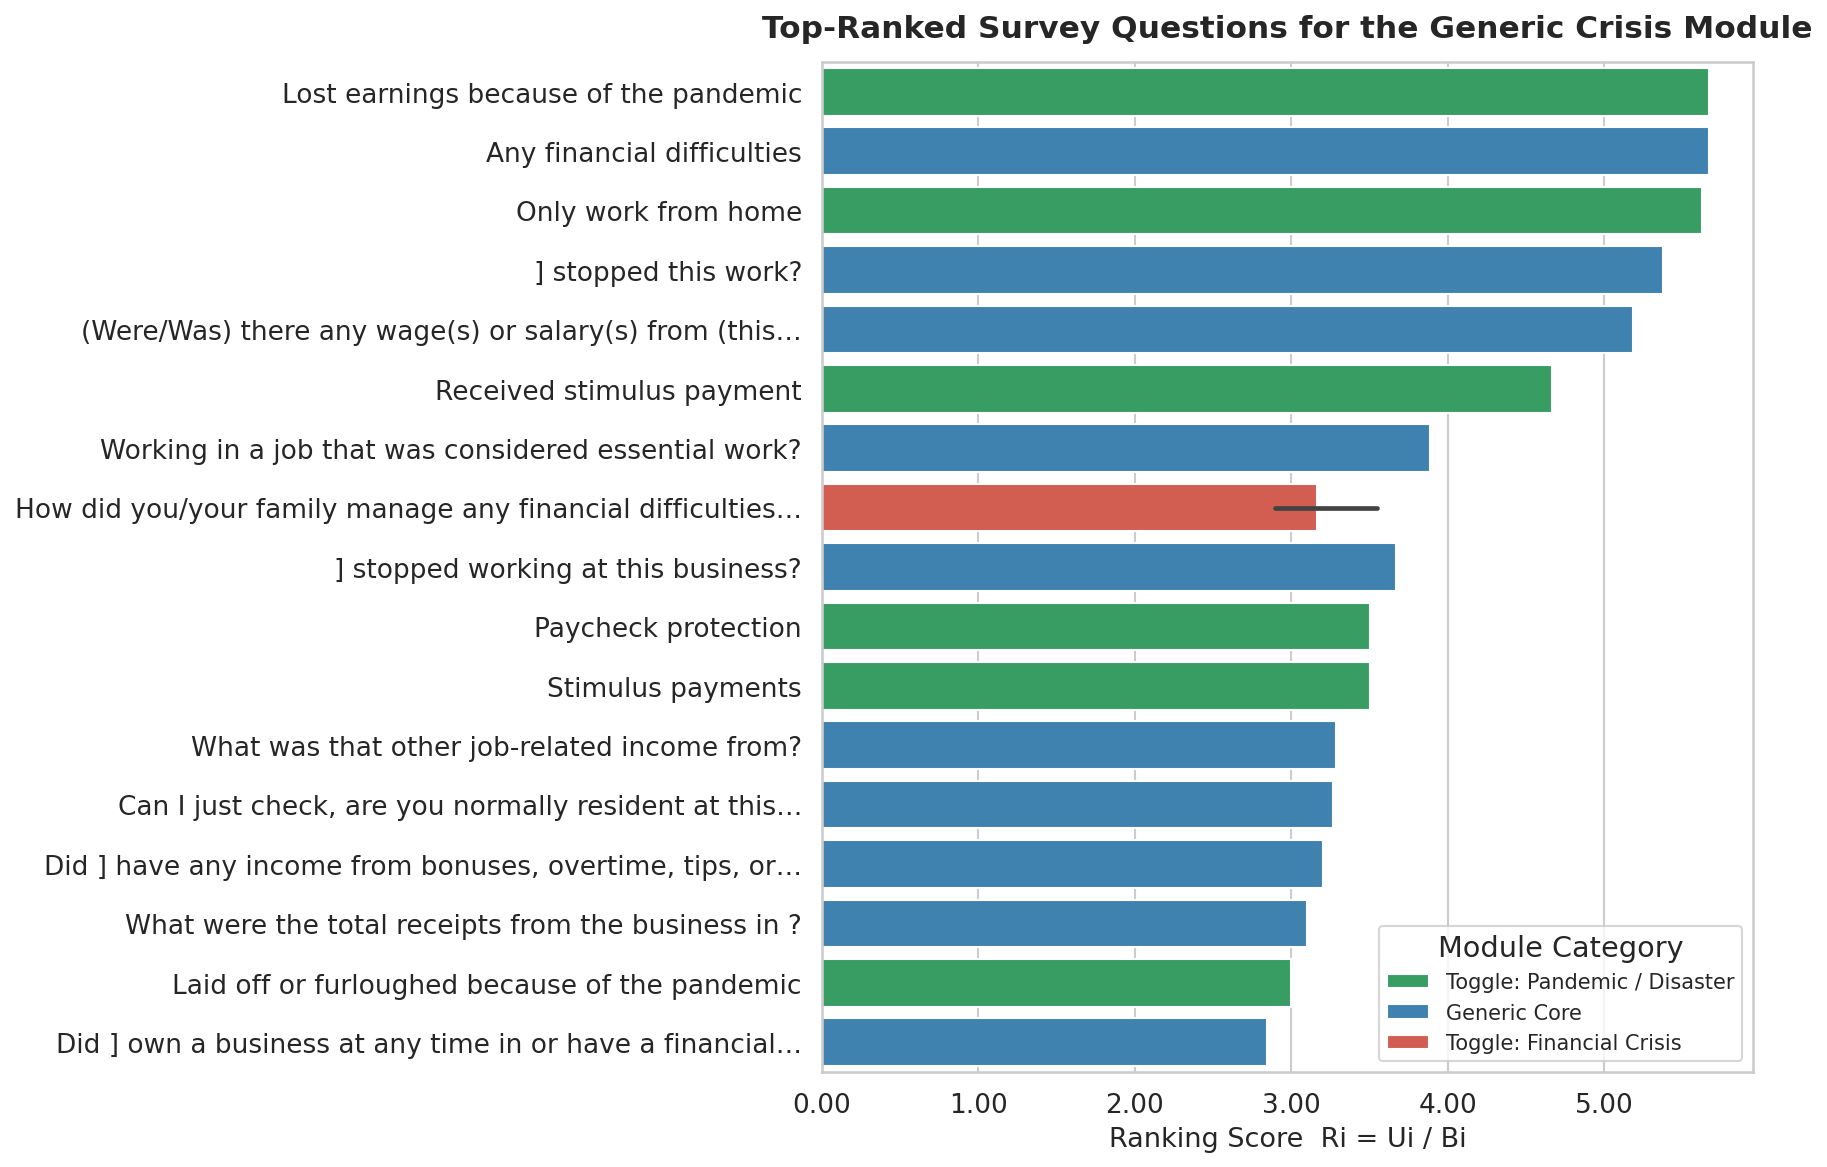

Saved: fig_top_ranked_questions.png


In [8]:
# ──────────────────────────────────────────────────────────────────────────
# 8a. BAR CHART — Top 20 questions by Ranking Score (Ri)
# ──────────────────────────────────────────────────────────────────────────

top_n = min(20, len(df))
plot_df = df.head(top_n).copy()
plot_df["short_q"] = plot_df["question_text"].apply(
    lambda t: textwrap.shorten(t, width=60, placeholder="…")
)

fig, ax = plt.subplots(figsize=(12, 8))
palette = {
    "Generic Core": "#2E86C1",
    "Toggle: Financial Crisis": "#E74C3C",
    "Toggle: Pandemic / Disaster": "#27AE60",
}
sns.barplot(
    data=plot_df,
    y="short_q",
    x="Ri",
    hue="toggle_category",
    dodge=False,
    palette=palette,
    ax=ax,
)
ax.set_xlabel("Ranking Score  Ri = Ui / Bi", fontsize=13)
ax.set_ylabel("")
ax.set_title("Top-Ranked Survey Questions for the Generic Crisis Module",
             fontsize=15, fontweight="bold", pad=12)
ax.legend(title="Module Category", loc="lower right", fontsize=10)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
plt.tight_layout()
plt.savefig("fig_top_ranked_questions.png", bbox_inches="tight")
plt.show()
print("Saved: fig_top_ranked_questions.png")

### 8b. Generic Core vs Crisis-Specific Toggle Comparison

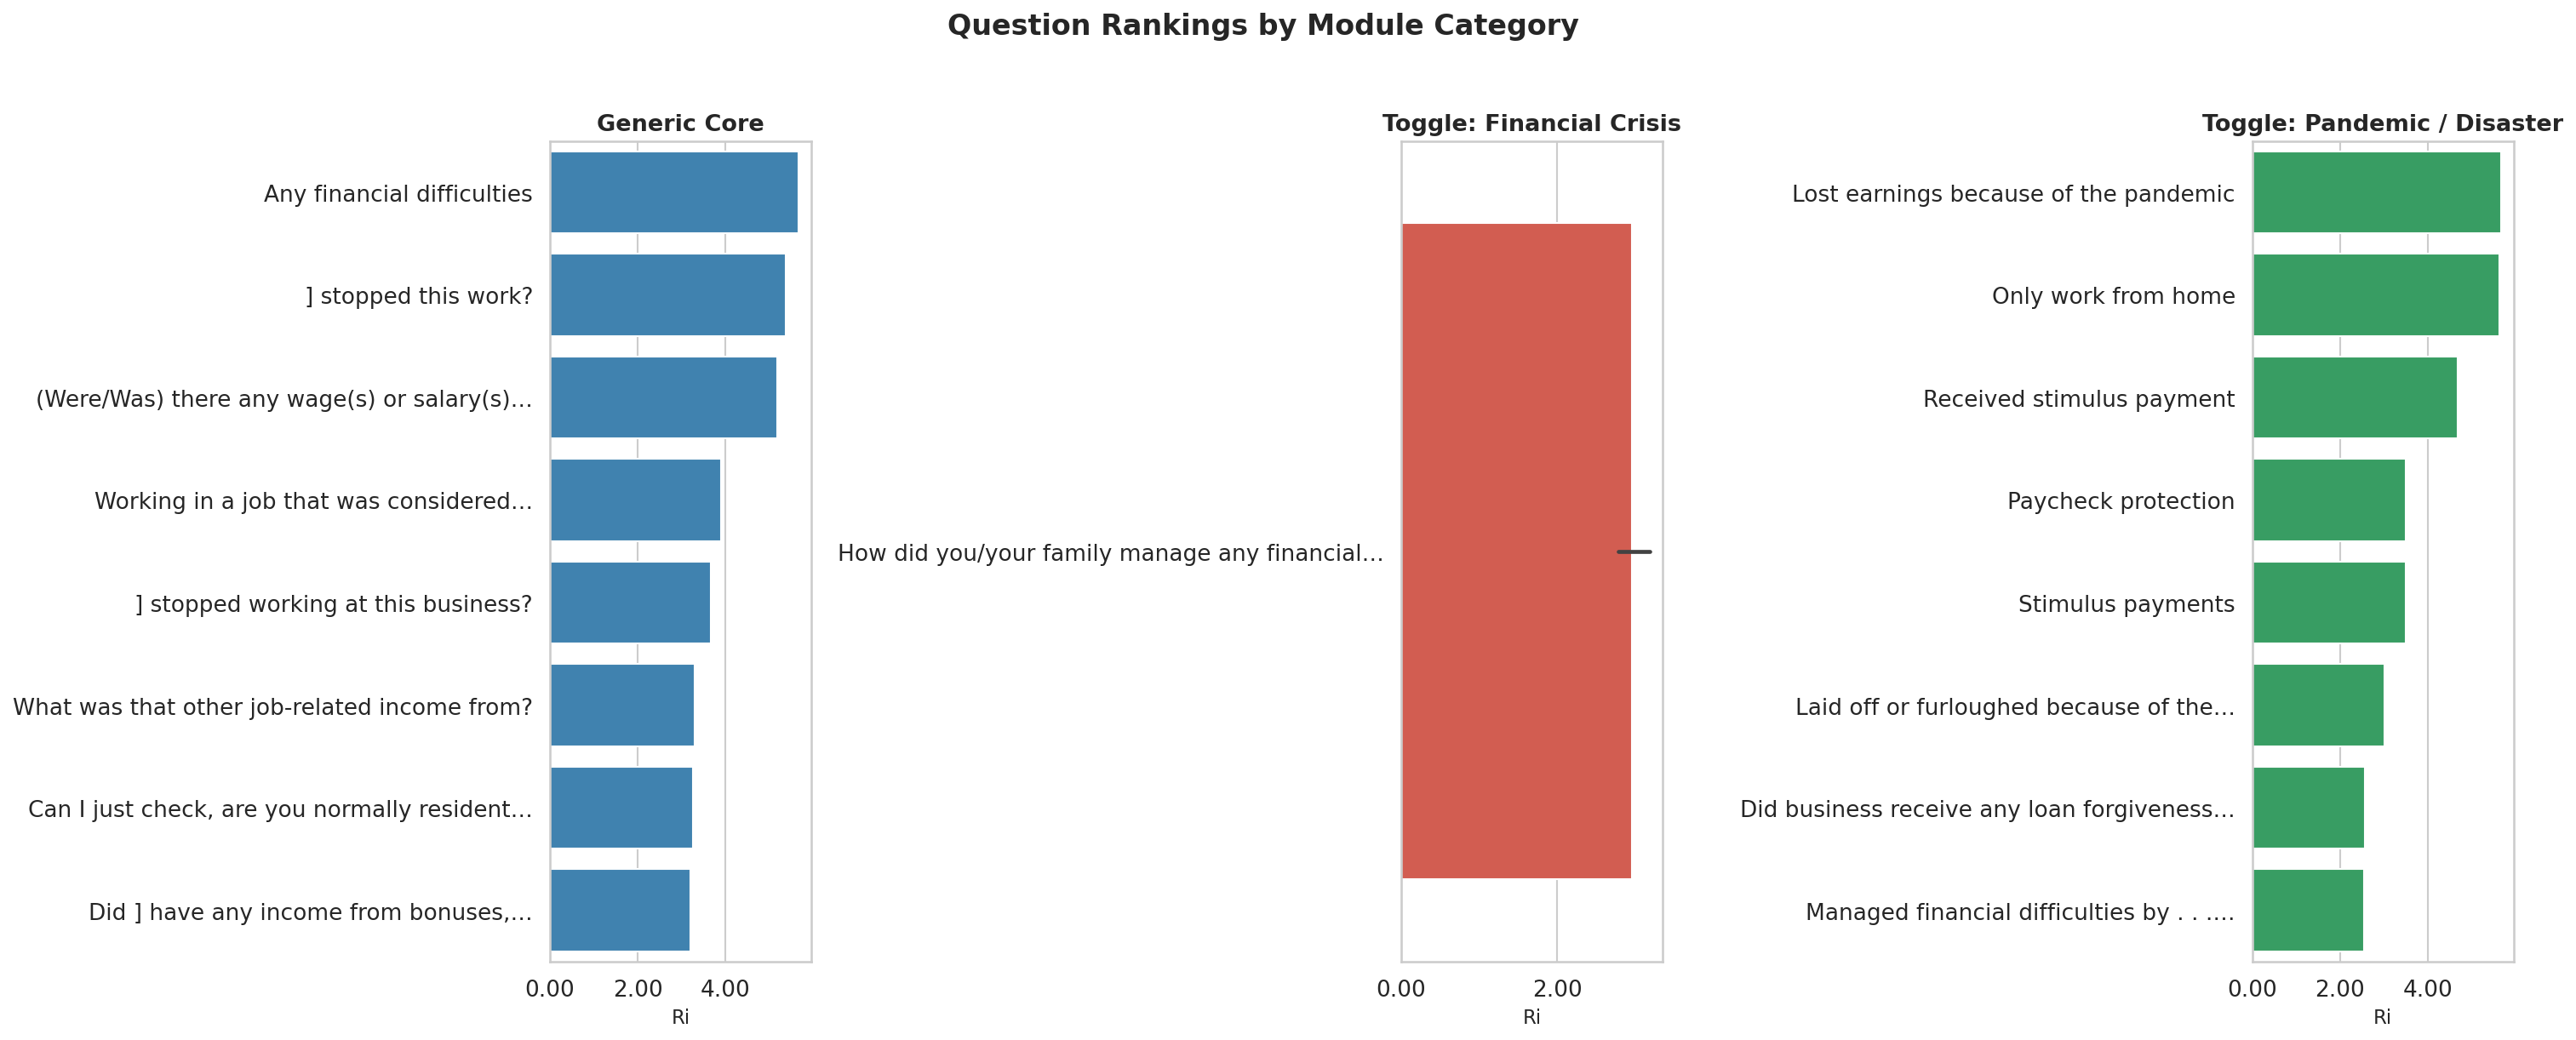

Saved: fig_toggle_comparison.png


In [9]:
# ──────────────────────────────────────────────────────────────────────────
# 8b. SIDE-BY-SIDE BAR CHART — Generic Core vs Toggle top questions
# ──────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=False)
categories = ["Generic Core", "Toggle: Financial Crisis", "Toggle: Pandemic / Disaster"]
colors = ["#2E86C1", "#E74C3C", "#27AE60"]

for ax, cat, color in zip(axes, categories, colors):
    sub = df[df["toggle_category"] == cat].head(8).copy()
    if sub.empty:
        ax.set_title(cat, fontsize=12, fontweight="bold")
        ax.text(0.5, 0.5, "No questions", transform=ax.transAxes, ha="center")
        continue
    sub["short_q"] = sub["question_text"].apply(
        lambda t: textwrap.shorten(t, width=45, placeholder="…")
    )
    sns.barplot(data=sub, y="short_q", x="Ri", color=color, ax=ax)
    ax.set_title(cat, fontsize=13, fontweight="bold")
    ax.set_xlabel("Ri", fontsize=11)
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

plt.suptitle("Question Rankings by Module Category",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig_toggle_comparison.png", bbox_inches="tight")
plt.show()
print("Saved: fig_toggle_comparison.png")

### 8c. Utility vs Burden — Efficiency Frontier

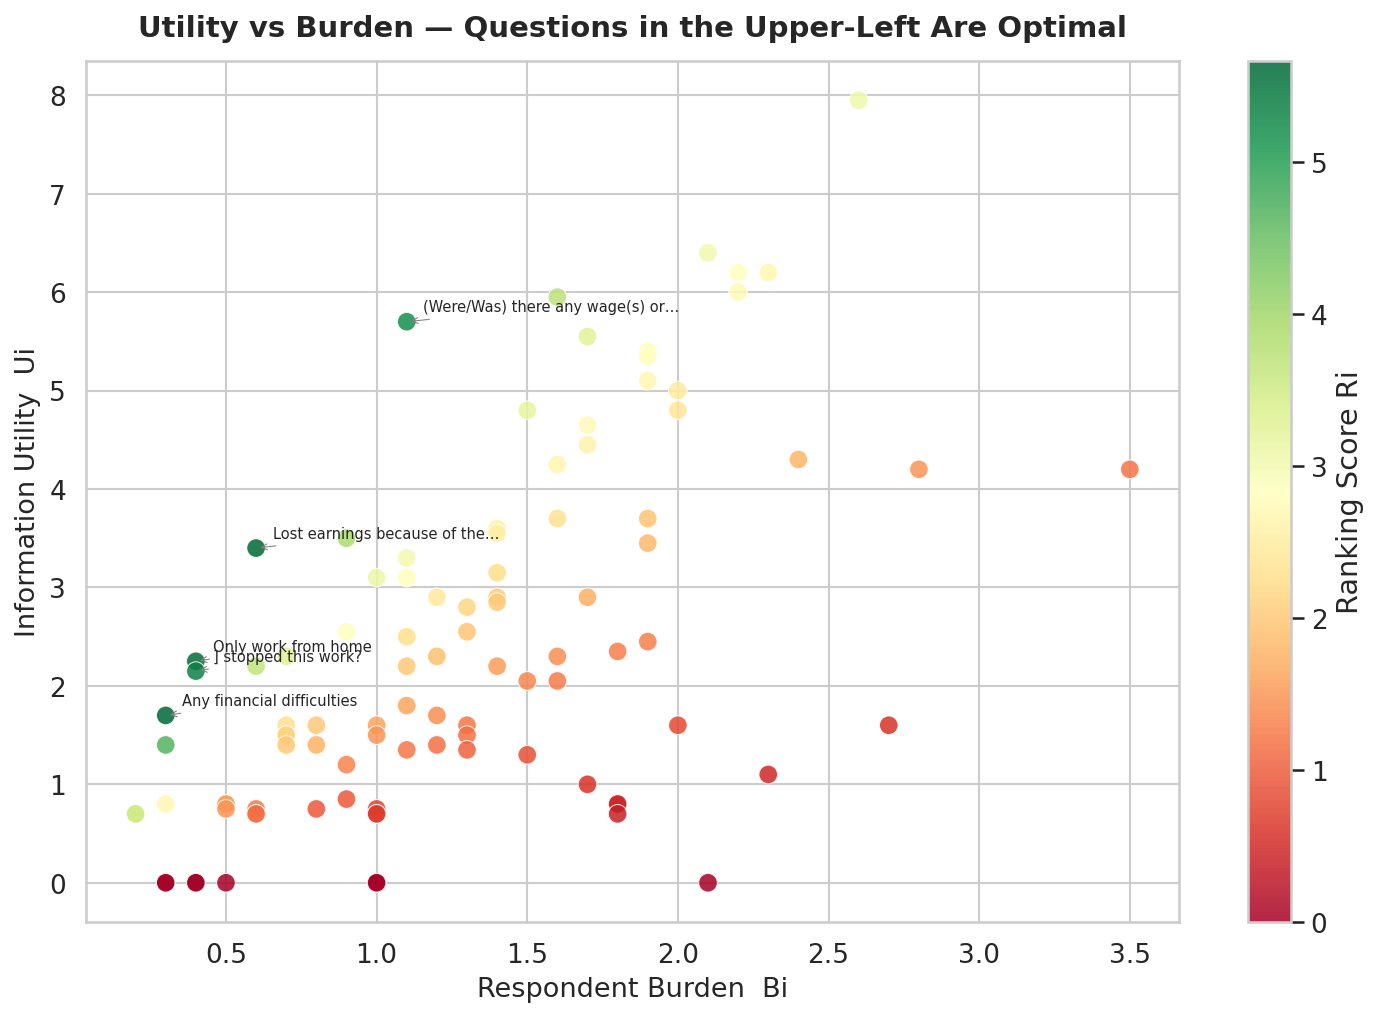

Saved: fig_utility_vs_burden.png


In [10]:
# ──────────────────────────────────────────────────────────────────────────
# 8c. SCATTER PLOT — Information Utility vs Respondent Burden
# ──────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    df["Bi"], df["Ui"],
    c=df["Ri"],
    cmap="RdYlGn",
    s=80,
    edgecolors="white",
    linewidth=0.5,
    alpha=0.85,
)
cbar = plt.colorbar(scatter, ax=ax, label="Ranking Score Ri")

# Annotate the top 5
for _, row in df.head(5).iterrows():
    ax.annotate(
        textwrap.shorten(row["question_text"], 35, placeholder="…"),
        (row["Bi"], row["Ui"]),
        fontsize=7,
        textcoords="offset points",
        xytext=(8, 5),
        arrowprops=dict(arrowstyle="->", color="gray", lw=0.5),
    )

ax.set_xlabel("Respondent Burden  Bi", fontsize=13)
ax.set_ylabel("Information Utility  Ui", fontsize=13)
ax.set_title("Utility vs Burden — Questions in the Upper-Left Are Optimal",
             fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("fig_utility_vs_burden.png", bbox_inches="tight")
plt.show()
print("Saved: fig_utility_vs_burden.png")

### 8d. Crisis Construct Heatmap by Source

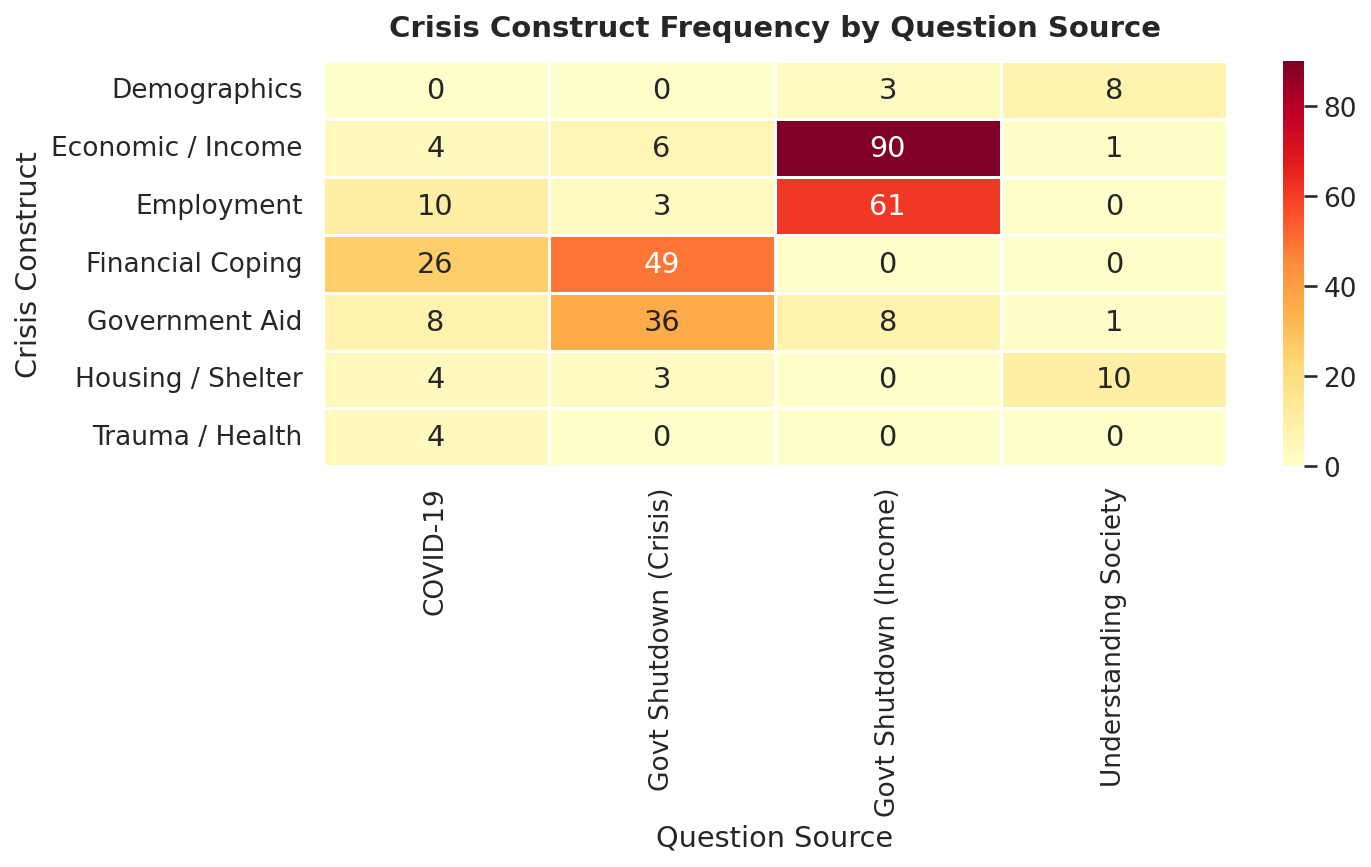

Saved: fig_construct_heatmap.png


In [11]:
# ──────────────────────────────────────────────────────────────────────────
# 8d. HEATMAP — construct frequency by source
# ──────────────────────────────────────────────────────────────────────────

construct_source = []
for _, row in df.iterrows():
    for t in row["tagged"]:
        construct_source.append({"construct": t["construct"], "source": row["source"]})

cs_df = pd.DataFrame(construct_source)
if len(cs_df):
    pivot = cs_df.pivot_table(index="construct", columns="source", aggfunc="size", fill_value=0)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, ax=ax)
    ax.set_title("Crisis Construct Frequency by Question Source",
                 fontsize=14, fontweight="bold", pad=12)
    ax.set_ylabel("Crisis Construct")
    ax.set_xlabel("Question Source")
    plt.tight_layout()
    plt.savefig("fig_construct_heatmap.png", bbox_inches="tight")
    plt.show()
    print("Saved: fig_construct_heatmap.png")

### 8e. Estimated Time Budget by Module Category

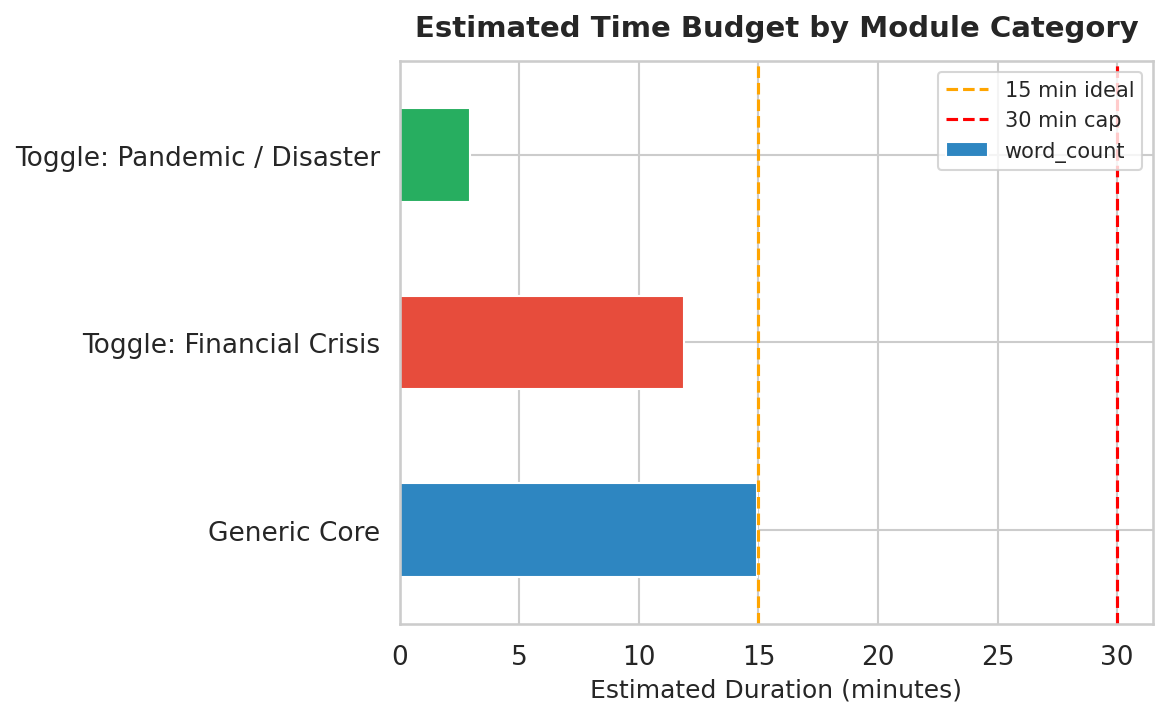

Saved: fig_time_budget.png


In [12]:
# ──────────────────────────────────────────────────────────────────────────
# 8e. STACKED BAR — estimated minutes per toggle category
# ──────────────────────────────────────────────────────────────────────────

selected = df[df["selected_for_module"]].copy()
time_budget = (
    selected
    .groupby("toggle_category")["word_count"]
    .sum()
    .mul(SECS_PER_WORD / 60)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
time_budget.plot.barh(
    color=[palette.get(c, "#888") for c in time_budget.index],
    edgecolor="white",
    ax=ax,
)
ax.axvline(x=15, color="orange", linestyle="--", linewidth=1.5, label="15 min ideal")
ax.axvline(x=30, color="red", linestyle="--", linewidth=1.5, label="30 min cap")
ax.set_xlabel("Estimated Duration (minutes)", fontsize=12)
ax.set_ylabel("")
ax.set_title("Estimated Time Budget by Module Category",
             fontsize=14, fontweight="bold", pad=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("fig_time_budget.png", bbox_inches="tight")
plt.show()
print("Saved: fig_time_budget.png")

## 9. Export Final Ranked Question Table

In [13]:
# ──────────────────────────────────────────────────────────────────────────
# 9.  EXPORT — save ranked questions to CSV
# ──────────────────────────────────────────────────────────────────────────

export_cols = [
    "question_text", "source", "module_type", "toggle_category",
    "keywords", "n_keywords", "n_tagged",
    "word_count", "complexity",
    "Ui", "Bi", "Ri",
    "selected_for_module",
]

output_path = "PSID_Ranked_Questions.csv"
df[export_cols].to_csv(output_path, index=False)
print(f"Exported ranked questions to: {output_path}")
print(f"Total rows: {len(df)}")
print(f"Selected for module: {df['selected_for_module'].sum()}")

# Final summary
print("\n" + "="*70)
print("PIPELINE COMPLETE")
print("="*70)
print(f"Questions analysed:   {len(df)}")
print(f"Keywords extracted:   {df['n_keywords'].sum()}")
print(f"Constructs tagged:    {df['n_tagged'].sum()}")
print(f"Module selected:      {df['selected_for_module'].sum()} questions")
print(f"Estimated duration:   {df[df['selected_for_module']]['word_count'].sum() * SECS_PER_WORD / 60:.1f} min")

Exported ranked questions to: PSID_Ranked_Questions.csv
Total rows: 103
Selected for module: 24

PIPELINE COMPLETE
Questions analysed:   103
Keywords extracted:   609
Constructs tagged:    335
Module selected:      24 questions
Estimated duration:   29.8 min
